## Equipo 48 - Nombres y Matriculas:

| ID         | Name                             |
|------------|----------------------------------|
| A01796245  | Oscar Luis Guadarrama Jiménez    |
| A01795463  | Luis Alejandro Juárez Rodríguez  |
| A01795188  | José Manuel Pérez González       |


# Análisis Exploratorio de Datos (EDA)
## Dataset: Producción Bovina — 24 Meses

| Parámetro | Valor |
|---|---|
| **Registros** | 73,000 |
| **Variables** | 35 |
| **Período** | Enero 2024 – Diciembre 2025 |
| **Animales** | 100 vacas únicas |
| **Razas** | Holstein · Jersey · Pardo Suizo |
| **Objetivo** | `leche_kg_dia` (regresión) · `mastitis` (clasificación) |

---


## 0. Instalación de dependencias

In [1]:
import subprocess, sys

pkgs = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scipy', 'openpyxl']
for pkg in pkgs:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print("✅ Dependencias instaladas")

✅ Dependencias instaladas


## 1. Importaciones y carga de datos

In [3]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# ── Paletas de color ──────────────────────────────────────────────────────────
PALETTE_RAZA  = {'Holstein':'#4C72B0', 'Jersey':'#DD8452', 'Pardo Suizo':'#55A868'}
PALETTE_STA   = {'Invierno':'#5B9BD5','Primavera':'#70AD47','Verano':'#FFC000','Otoño':'#FF7C41'}
COLORS        = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']

# ── Carga ─────────────────────────────────────────────────────────────────────
DATASET_PATH = "E:\Tareas\scrum\dataset_dummy_vacas_24m_v2.xlsx"

df = pd.read_excel(DATASET_PATH)
df['fecha'] = pd.to_datetime(df['fecha'])
df['anio_mes'] = df['fecha'].dt.to_period('M')

print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Período: {df['fecha'].min().date()} → {df['fecha'].max().date()}")
df.head()

Dataset cargado: 73,000 filas × 36 columnas
Período: 2024-01-01 → 2025-12-30


,fecha,anio,mes,dia_semana,estacion,id_vaca,nombre_vaca,raza,sistema_produccion,edad_meses,...,leche_kg_dia,grasa_pct,proteina_leche_pct,lactosa_pct,omega3_mg_l,antioxidantes_ppm,mastitis,celulas_somaticas,condicion_corporal,anio_mes
0,2024-01-01,2024,1,Monday,Invierno,VAC_001,Vaca_001,Jersey,Pastoreo,90,...,25.40,3.75,3.18,4.89,252.44,11.29,0,184219,2.57,2024-01
1,2024-01-02,2024,1,Tuesday,Invierno,VAC_001,Vaca_001,Jersey,Pastoreo,90,...,26.35,3.87,3.17,4.77,255.21,8.58,0,175273,3.30,2024-01
2,2024-01-03,2024,1,Wednesday,Invierno,VAC_001,Vaca_001,Jersey,Pastoreo,90,...,24.16,4.13,3.26,4.53,251.83,17.18,0,231267,3.45,2024-01
3,2024-01-04,2024,1,Thursday,Invierno,VAC_001,Vaca_001,Jersey,Pastoreo,90,...,25.46,4.12,3.21,4.86,239.41,14.90,0,145252,2.81,2024-01
4,2024-01-05,2024,1,Friday,Invierno,VAC_001,Vaca_001,Jersey,Pastoreo,90,...,22.93,3.81,3.07,4.99,230.32,11.10,0,181412,3.42,2024-01


## 2. Vista general del dataset
### 2.1 Tipos de datos y estructura

In [4]:
# Resumen de tipos de datos
info_df = pd.DataFrame({
    'Dtype'      : df.dtypes,
    'No Nulos'   : df.notnull().sum(),
    'Nulos'      : df.isnull().sum(),
    'Nulos %'    : (df.isnull().sum() / len(df) * 100).round(2),
    'Únicos'     : df.nunique(),
    'Muestra'    : [df[c].dropna().iloc[0] if df[c].notnull().any() else None for c in df.columns]
})
info_df

,Dtype,No Nulos,Nulos,Nulos %,Únicos,Muestra
fecha,datetime64[ns],73000,0,0.0,730,2024-01-01 00:00:00
anio,int64,73000,0,0.0,2,2024
mes,int64,73000,0,0.0,12,1
dia_semana,object,73000,0,0.0,7,Monday
estacion,object,73000,0,0.0,4,Invierno
id_vaca,object,73000,0,0.0,100,VAC_001
nombre_vaca,object,73000,0,0.0,100,Vaca_001
raza,object,73000,0,0.0,3,Jersey
sistema_produccion,object,73000,0,0.0,3,Pastoreo
edad_meses,int64,73000,0,0.0,96,90


### 2.2 Estadísticas descriptivas — Variables numéricas

In [5]:
num_cols = df.select_dtypes(include='number').columns.tolist()
desc = df[num_cols].describe().T
desc['skewness'] = df[num_cols].skew()
desc['kurtosis'] = df[num_cols].kurtosis()
desc.style.background_gradient(cmap='YlOrRd', subset=['skewness','kurtosis'])

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
anio,73000.000000,2024.498630,0.500002,2024.000000,2024.000000,2024.000000,2025.000000,2025.000000,0.005480,-2.000025
mes,73000.000000,6.512329,3.445964,1.000000,4.000000,7.000000,10.000000,12.000000,-0.007143,-1.207927
edad_meses,73000.000000,72.161233,22.642621,24.000000,54.000000,72.000000,91.000000,119.000000,0.006669,-0.923342
numero_lactancia,73000.000000,3.090000,1.357175,1.000000,2.000000,3.000000,4.000000,5.000000,-0.067225,-1.260654
peso_kg,73000.000000,615.220578,58.515569,381.350000,577.220000,622.155000,653.550000,789.830000,-0.665231,1.411808
temperatura_c,73000.000000,21.990346,5.995550,8.000000,16.650000,21.960000,27.320000,38.030000,-0.000015,-1.187246
humedad_pct,73000.000000,59.970924,11.735281,30.000000,50.100000,59.980000,69.820000,90.800000,0.000398,-0.998890
precipitacion_mm,73000.000000,4.926924,4.740178,0.000000,0.000000,4.035000,8.080000,31.610000,0.835101,0.066570
indice_thi,73000.000000,68.977451,8.946433,48.780000,60.930000,68.490000,76.900000,94.230000,0.104321,-1.193081
estres_termico,73000.000000,0.405603,0.491012,0.000000,0.000000,0.000000,1.000000,1.000000,0.384512,-1.852202


### 2.3 Variables categóricas — Cardinalidad

In [7]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
card_df = pd.DataFrame({
    'Cardinalidad' : [df[c].nunique() for c in cat_cols],
    'Categorías'   : [', '.join(df[c].unique()[:5].astype(str)) for c in cat_cols],
    'Top valor'    : [df[c].value_counts().index[0] for c in cat_cols],
    'Top freq %'   : [(df[c].value_counts().iloc[0]/len(df)*100).round(1) for c in cat_cols]
}, index=cat_cols)
card_df

,Cardinalidad,Categorías,Top valor,Top freq %
dia_semana,7,"Monday, Tuesday, Wednesday, Thursday, Friday",Monday,14.4
estacion,4,"Invierno, Primavera, Verano, Otoño",Primavera,25.2
id_vaca,100,"VAC_001, VAC_002, VAC_003, VAC_004, VAC_005",VAC_001,1.0
nombre_vaca,100,"Vaca_001, Vaca_002, Vaca_003, Vaca_004, Vaca_005",Vaca_001,1.0
raza,3,"Jersey, Holstein, Pardo Suizo",Holstein,66.0
sistema_produccion,3,"Pastoreo, Semi-Intensivo, Intensivo",Pastoreo,43.0
tipo_alimento,4,"Omega Plus, Alta Energia, Alta Fibra, Base",Alta Fibra,28.0
aditivo_1,4,"Taninos, Algas, Probióticos, Ninguno",Ninguno,39.0
aditivo_2,4,"Ninguno, Aceites, Minerales, Levadura",Ninguno,45.0


## 3. Análisis de Valores Faltantes

> **Pregunta EDA:** ¿Hay valores faltantes? ¿Se identifican patrones de ausencia?

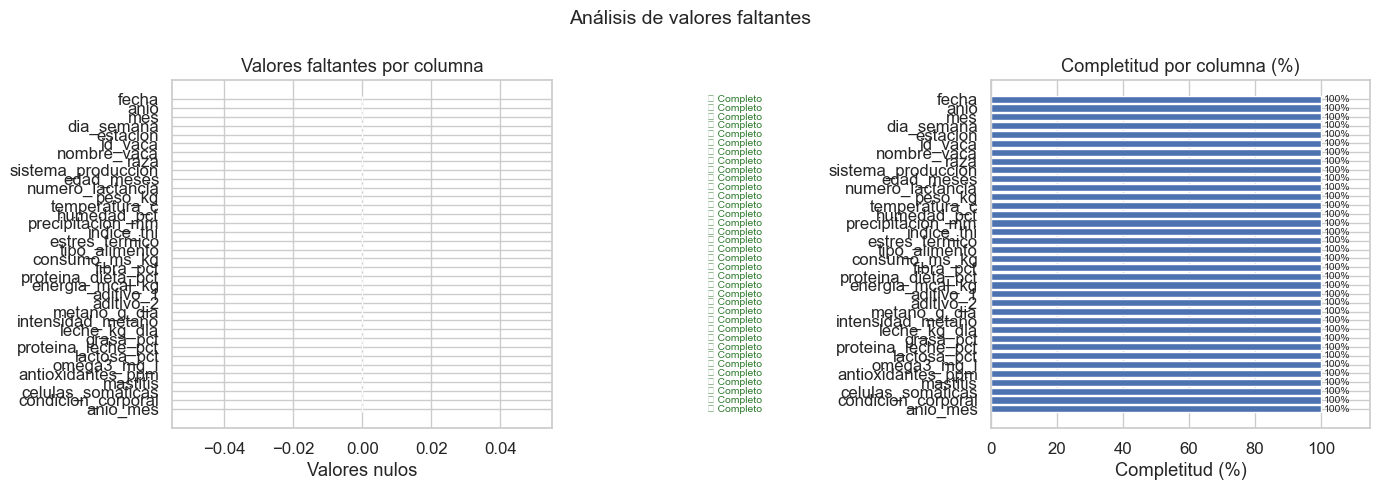


📊 Total de valores nulos: 0
✅ El dataset está 100% completo — no requiere imputación.


In [8]:
nulls = df.isnull().sum()
pct   = nulls / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: conteo
axes[0].barh(nulls.index[::-1], nulls.values[::-1], color='#55A868')
axes[0].set_xlabel('Valores nulos')
axes[0].set_title('Valores faltantes por columna')
for i, v in enumerate(nulls.values[::-1]):
    axes[0].text(0.1, i, '✓ Completo' if v == 0 else str(v),
                 va='center', fontsize=7.5, color='#2d7a2d' if v==0 else '#c44e52')

# Panel derecho: % completitud
axes[1].barh(pct.index[::-1], 100 - pct.values[::-1], color='#4C72B0')
axes[1].set_xlabel('Completitud (%)')
axes[1].set_xlim(0, 115)
axes[1].set_title('Completitud por columna (%)')
for i, v in enumerate(pct.values[::-1]):
    axes[1].text(101, i, f'{100-v:.0f}%', va='center', fontsize=7.5)

plt.suptitle('Análisis de valores faltantes', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\n📊 Total de valores nulos: {nulls.sum()}")
print(f"✅ El dataset está 100% completo — no requiere imputación.")

## 4. Análisis Univariante

### 4.1 Distribuciones de variables numéricas

> **Pregunta EDA:** ¿Existen distribuciones sesgadas? ¿Necesitamos transformaciones?

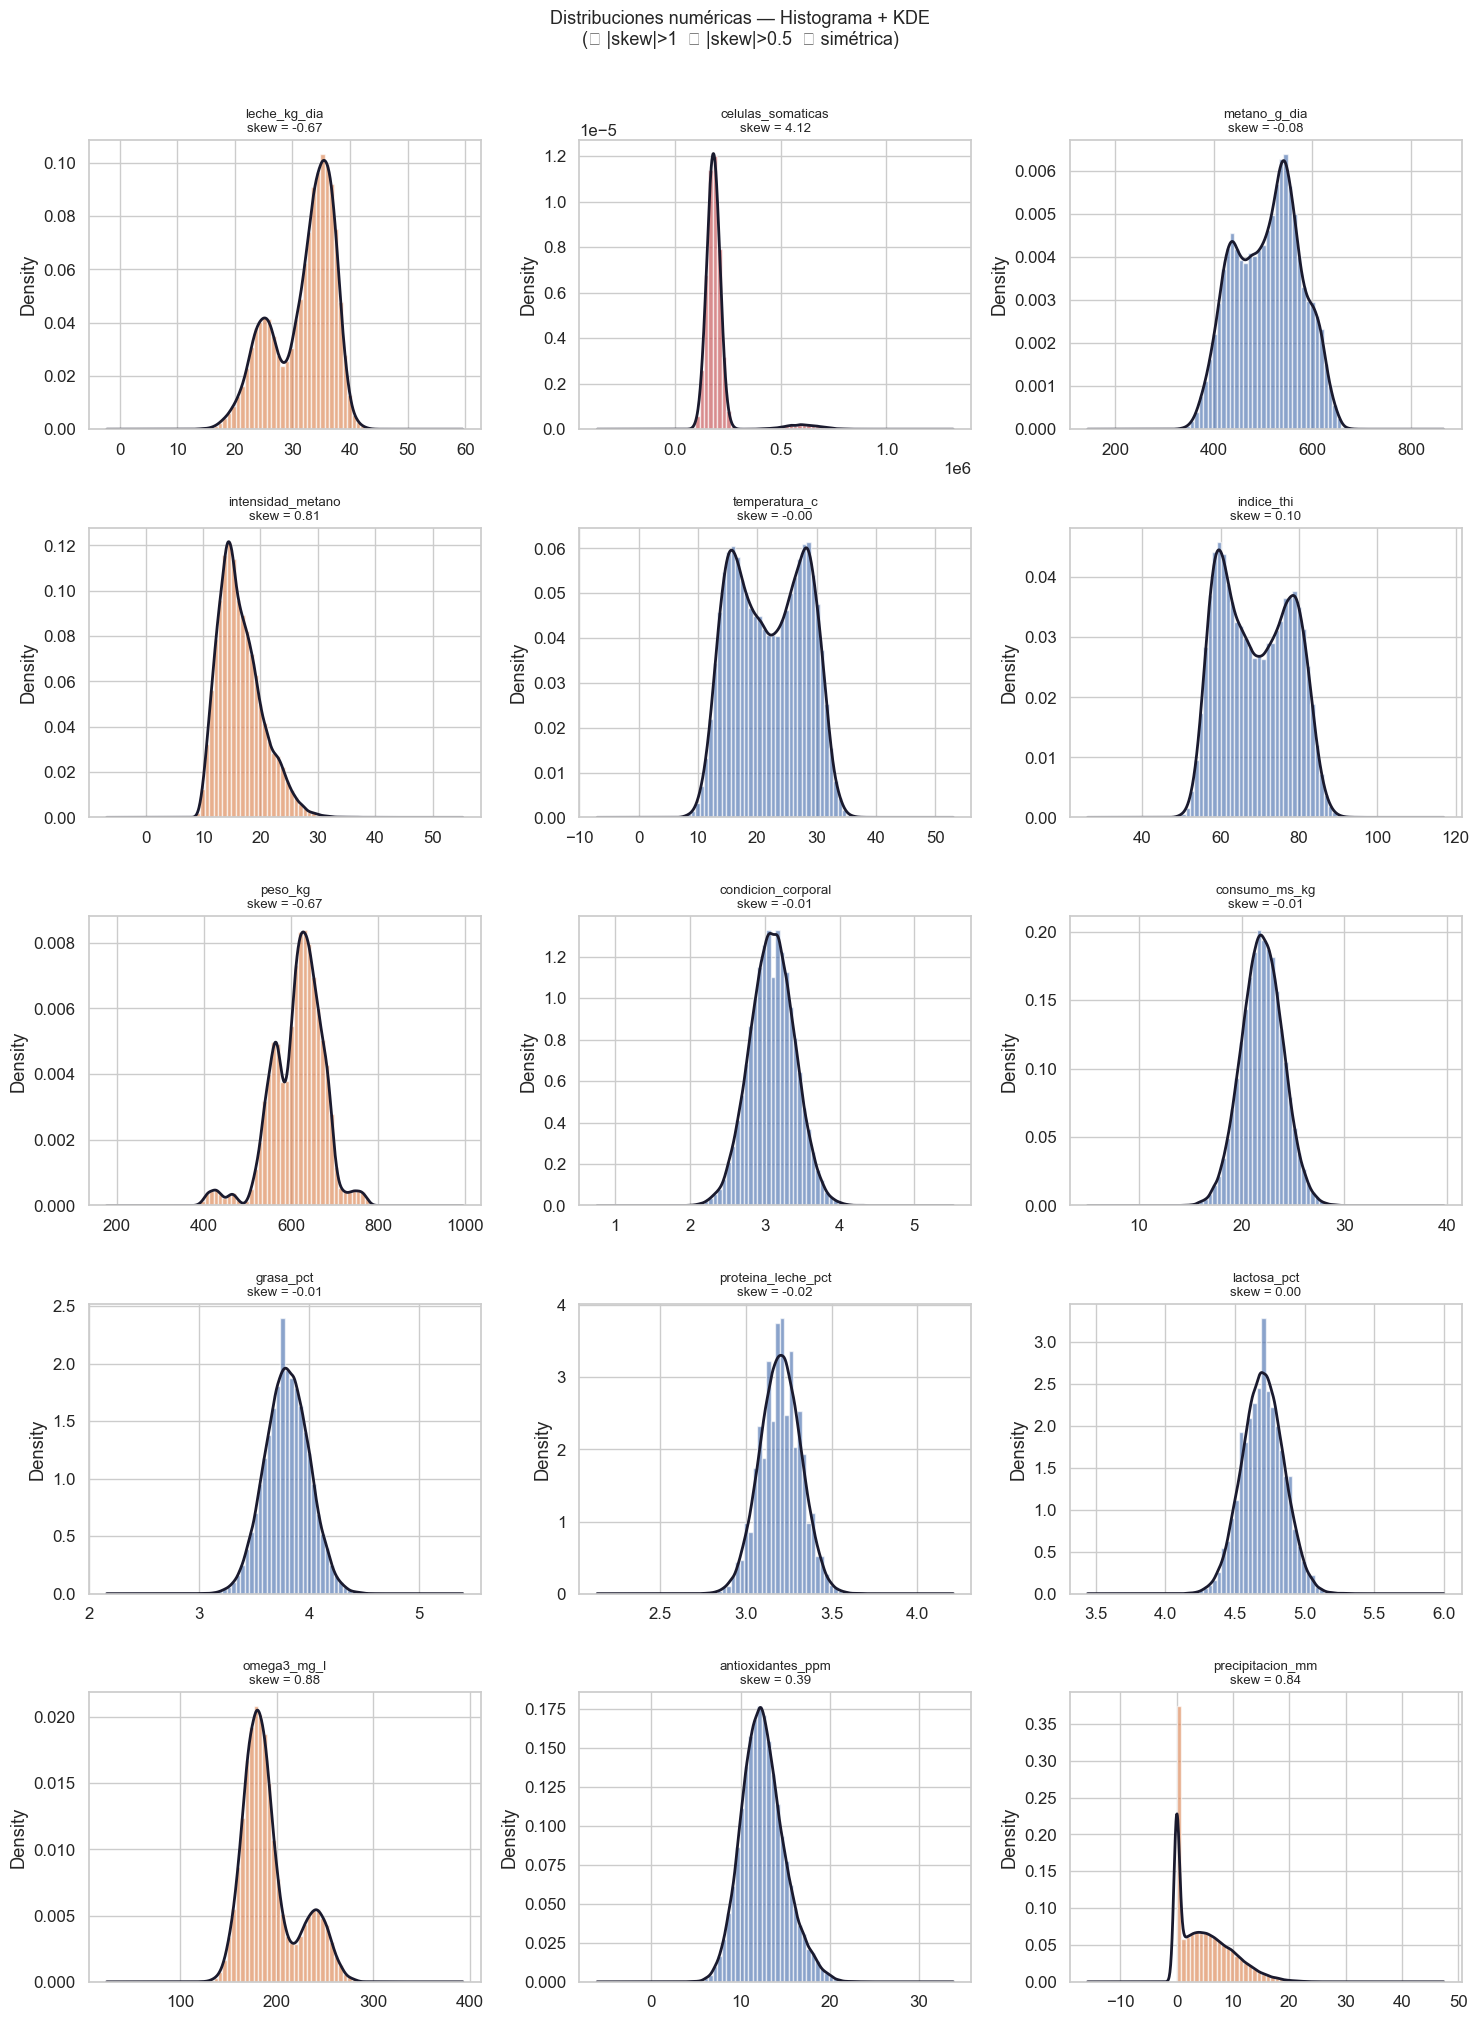

In [9]:
num_plot = ['leche_kg_dia','celulas_somaticas','metano_g_dia','intensidad_metano',
            'temperatura_c','indice_thi','peso_kg','condicion_corporal',
            'consumo_ms_kg','grasa_pct','proteina_leche_pct','lactosa_pct',
            'omega3_mg_l','antioxidantes_ppm','precipitacion_mm']

fig, axes = plt.subplots(5, 3, figsize=(15, 20))

for ax, col in zip(axes.flat, num_plot):
    skew_val = df[col].skew()
    color = '#C44E52' if abs(skew_val) > 1 else ('#DD8452' if abs(skew_val) > 0.5 else '#4C72B0')
    ax.hist(df[col].dropna(), bins=40, color=color, alpha=0.65, density=True, edgecolor='white')
    df[col].dropna().plot.kde(ax=ax, color='#1a1a2e', lw=2)
    ax.set_title(f'{col}\nskew = {skew_val:.2f}', fontsize=9.5)
    ax.set_xlabel('')

plt.suptitle('Distribuciones numéricas — Histograma + KDE\n'
             '(🔴 |skew|>1  🟡 |skew|>0.5  🔵 simétrica)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 4.2 Tabla de sesgo (skewness)

In [10]:
skew_df = df[num_plot].skew().rename('Skewness').to_frame()
skew_df['|Skewness|'] = skew_df['Skewness'].abs()
skew_df['Nivel'] = skew_df['|Skewness|'].apply(
    lambda x: '🔴 Alto (>1) — transformación recomendada' if x > 1
              else ('🟡 Moderado (0.5–1)' if x > 0.5 else '🟢 Simétrico (<0.5)'))
skew_df.sort_values('|Skewness|', ascending=False)

,Skewness,|Skewness|,Nivel
celulas_somaticas,4.117215,4.117215,🔴 Alto (>1) — transformación recomendada
omega3_mg_l,0.883357,0.883357,🟡 Moderado (0.5–1)
precipitacion_mm,0.835101,0.835101,🟡 Moderado (0.5–1)
intensidad_metano,0.805885,0.805885,🟡 Moderado (0.5–1)
leche_kg_dia,-0.669548,0.669548,🟡 Moderado (0.5–1)
peso_kg,-0.665231,0.665231,🟡 Moderado (0.5–1)
antioxidantes_ppm,0.392564,0.392564,🟢 Simétrico (<0.5)
indice_thi,0.104321,0.104321,🟢 Simétrico (<0.5)
metano_g_dia,-0.080190,0.080190,🟢 Simétrico (<0.5)
proteina_leche_pct,-0.020282,0.020282,🟢 Simétrico (<0.5)


### 4.3 Variables categóricas — Frecuencias

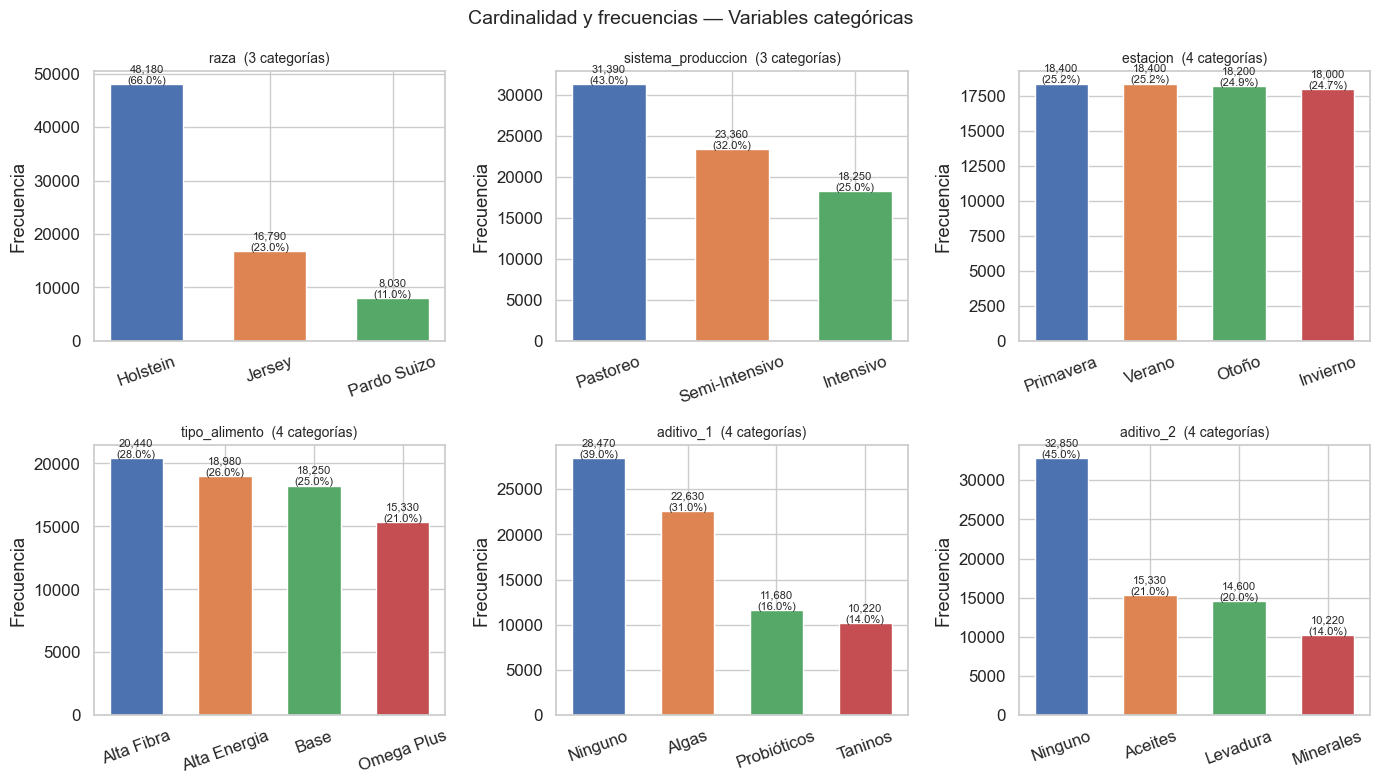

In [11]:
cat_plot = ['raza','sistema_produccion','estacion','tipo_alimento','aditivo_1','aditivo_2']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, col in zip(axes.flat, cat_plot):
    vc = df[col].value_counts()
    bars = ax.bar(vc.index, vc.values, color=COLORS[:len(vc)], edgecolor='white', width=0.6)
    ax.set_title(f'{col}  ({df[col].nunique()} categorías)', fontsize=10)
    ax.set_ylabel('Frecuencia')
    for bar, v in zip(bars, vc.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=8)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Cardinalidad y frecuencias — Variables categóricas', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Detección de Valores Atípicos

> **Pregunta EDA:** ¿Hay outliers en el dataset?

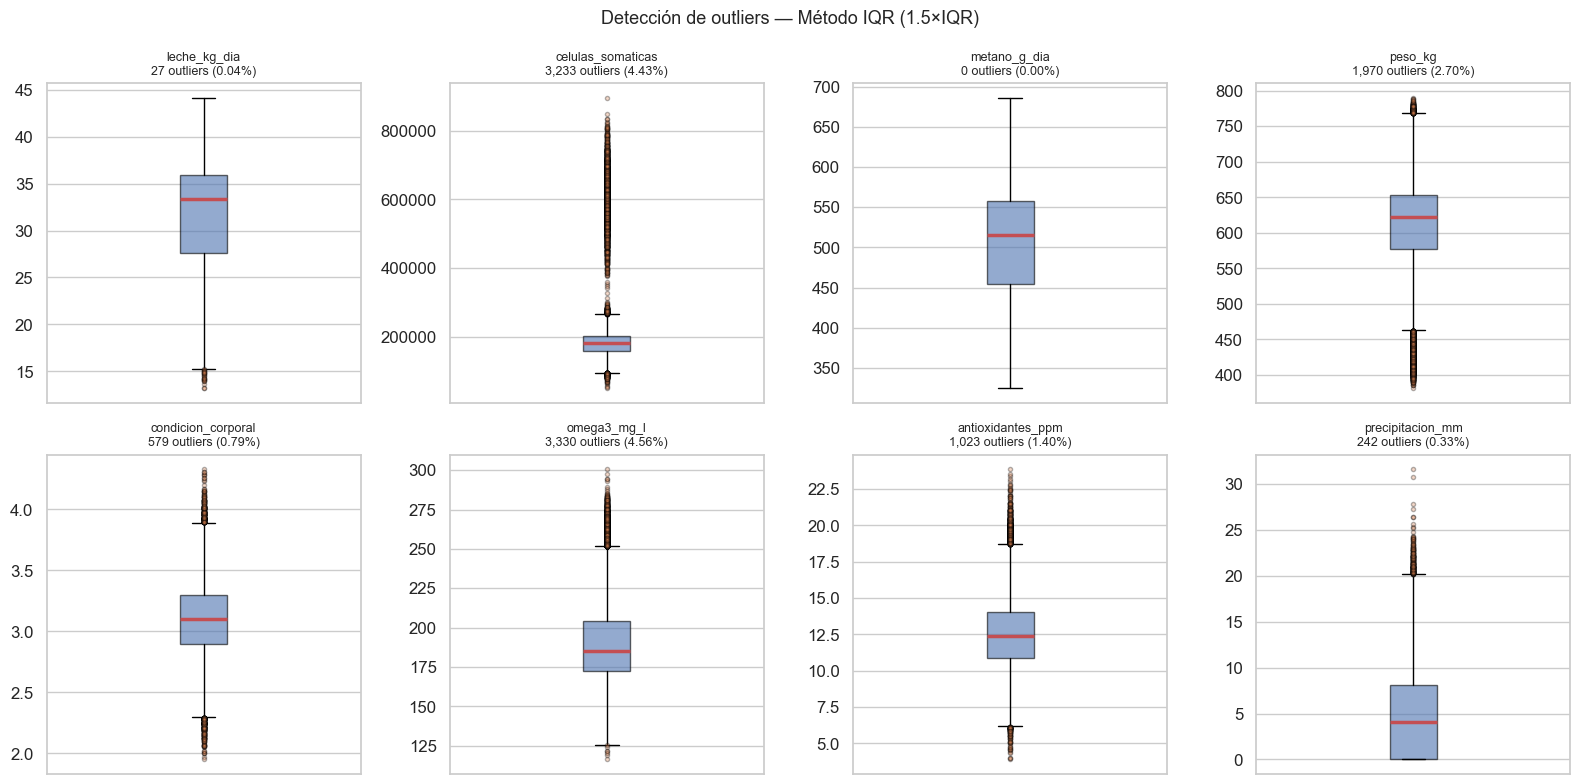

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
cols_box = ['leche_kg_dia','celulas_somaticas','metano_g_dia','peso_kg',
            'condicion_corporal','omega3_mg_l','antioxidantes_ppm','precipitacion_mm']

for ax, col in zip(axes.flat, cols_box):
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)).sum()
    pct_out = n_out / len(df) * 100

    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#4C72B0', alpha=0.6),
               medianprops=dict(color='#C44E52', lw=2.5),
               flierprops=dict(marker='o', markerfacecolor='#DD8452', alpha=0.3, markersize=3))
    ax.set_title(f'{col}\n{n_out:,} outliers ({pct_out:.2f}%)', fontsize=9)
    ax.set_xticks([])

plt.suptitle('Detección de outliers — Método IQR (1.5×IQR)', fontsize=13)
plt.tight_layout()
plt.show()

### 5.1 Resumen de outliers por variable

In [13]:
outlier_results = []
for col in df.select_dtypes(include='number').columns:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    low  = Q1 - 1.5*IQR
    high = Q3 + 1.5*IQR
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    outlier_results.append({
        'Variable'     : col,
        'Q1'           : round(Q1, 2),
        'Q3'           : round(Q3, 2),
        'IQR'          : round(IQR, 2),
        'Límite inf.'  : round(low, 2),
        'Límite sup.'  : round(high, 2),
        'N Outliers'   : n_out,
        'Outliers %'   : round(n_out/len(df)*100, 2),
        'Acción'       : 'Transformación log' if col=='celulas_somaticas'
                         else ('Revisar por raza' if col=='peso_kg'
                         else ('Winsorizar' if n_out>100 else 'Conservar'))
    })

out_df = pd.DataFrame(outlier_results).sort_values('N Outliers', ascending=False)
out_df[out_df['N Outliers'] > 0].style.bar(subset=['Outliers %'], color='#ffb3b3')

,Variable,Q1,Q3,IQR,Límite inf.,Límite sup.,N Outliers,Outliers %,Acción
20,omega3_mg_l,172.730000,204.390000,31.660000,125.240000,251.880000,3330,4.560000,Winsorizar
23,celulas_somaticas,160694.750000,203461.000000,42766.250000,96545.380000,267610.380000,3233,4.430000,Transformación log
22,mastitis,0.000000,0.000000,0.000000,0.000000,0.000000,2917,4.000000,Winsorizar
4,peso_kg,577.220000,653.550000,76.330000,462.730000,768.040000,1970,2.700000,Revisar por raza
15,intensidad_metano,13.690000,18.780000,5.090000,6.050000,26.420000,1120,1.530000,Winsorizar
21,antioxidantes_ppm,10.880000,14.020000,3.140000,6.170000,18.740000,1023,1.400000,Winsorizar
18,proteina_leche_pct,3.120000,3.280000,0.160000,2.880000,3.520000,611,0.840000,Winsorizar
24,condicion_corporal,2.900000,3.300000,0.400000,2.300000,3.900000,579,0.790000,Winsorizar
13,energia_mcal_kg,1.500000,1.700000,0.200000,1.200000,2.000000,541,0.740000,Winsorizar
19,lactosa_pct,4.600000,4.800000,0.200000,4.300000,5.100000,535,0.730000,Winsorizar


### 5.2 Transformación logarítmica — células somáticas

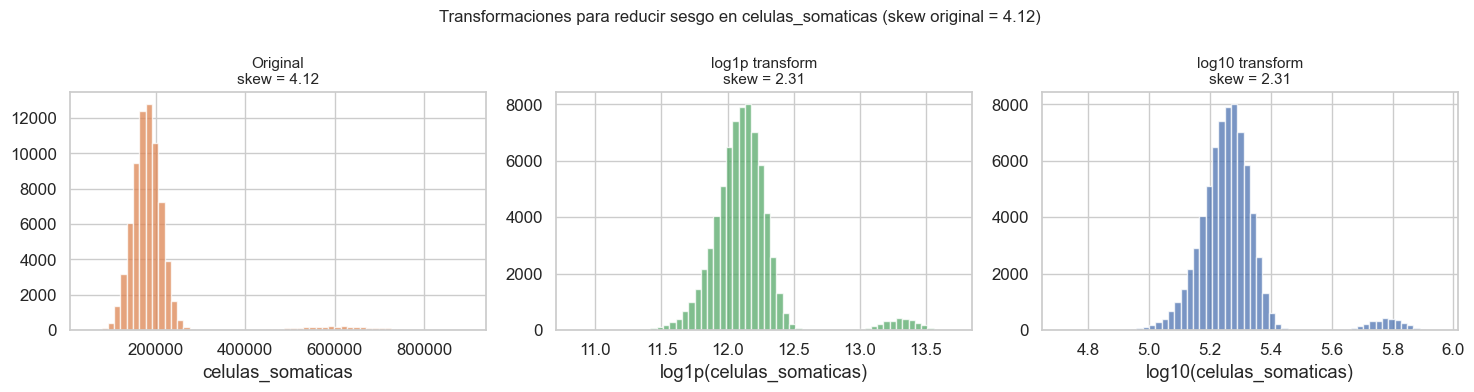

✅ Conclusión: log1p o log10 normalizan exitosamente la distribución.
   Original  → skew = 4.12
   log1p     → skew = 2.31
   log10     → skew = 2.31


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original
axes[0].hist(df['celulas_somaticas'], bins=60, color='#DD8452', alpha=0.75, edgecolor='white')
axes[0].set_title(f'Original\nskew = {df["celulas_somaticas"].skew():.2f}', fontsize=11)
axes[0].set_xlabel('celulas_somaticas')

# log1p
log1p = np.log1p(df['celulas_somaticas'])
axes[1].hist(log1p, bins=60, color='#55A868', alpha=0.75, edgecolor='white')
axes[1].set_title(f'log1p transform\nskew = {log1p.skew():.2f}', fontsize=11)
axes[1].set_xlabel('log1p(celulas_somaticas)')

# log10
log10 = np.log10(df['celulas_somaticas'])
axes[2].hist(log10, bins=60, color='#4C72B0', alpha=0.75, edgecolor='white')
axes[2].set_title(f'log10 transform\nskew = {log10.skew():.2f}', fontsize=11)
axes[2].set_xlabel('log10(celulas_somaticas)')

plt.suptitle('Transformaciones para reducir sesgo en celulas_somaticas (skew original = 4.12)', fontsize=12)
plt.tight_layout()
plt.show()

print("✅ Conclusión: log1p o log10 normalizan exitosamente la distribución.")
print(f"   Original  → skew = {df['celulas_somaticas'].skew():.2f}")
print(f"   log1p     → skew = {log1p.skew():.2f}")
print(f"   log10     → skew = {log10.skew():.2f}")

## 6. Balance de Clases — Variables Objetivo

> **Pregunta EDA:** ¿Hay desequilibrio en las clases de la variable objetivo?

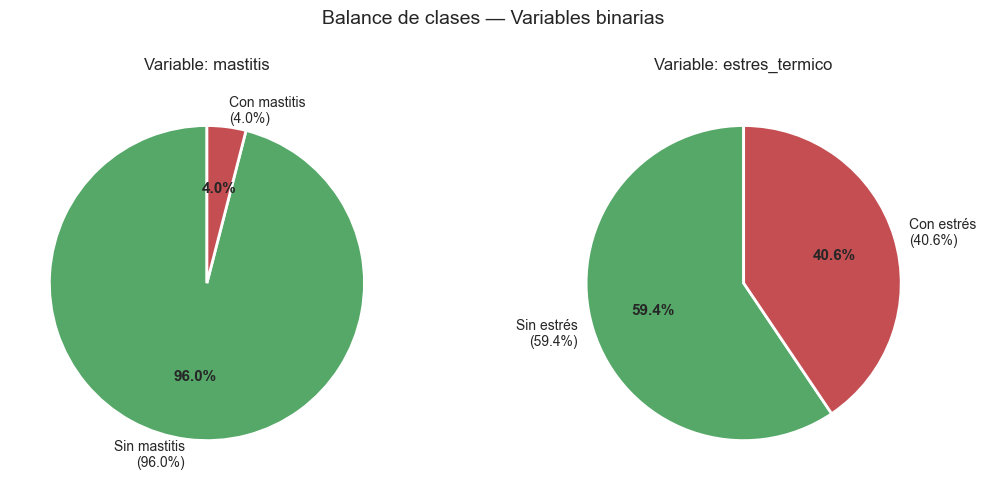


mastitis:
mastitis
0    70083
1     2917
  Ratio de desbalance: 24.0:1 → ⚠️ DESBALANCE SEVERO

estres_termico:
estres_termico
0    43391
1    29609
  Ratio de desbalance: 1.5:1 → 🟡 Moderado


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, col, labels in zip(axes,
        ['mastitis', 'estres_termico'],
        [['Sin mastitis', 'Con mastitis'], ['Sin estrés', 'Con estrés']]):
    vc  = df[col].value_counts().sort_index()
    pct = vc / vc.sum() * 100
    wedges, texts, autotexts = ax.pie(
        pct, labels=[f'{l}\n({p:.1f}%)' for l, p in zip(labels, pct)],
        autopct='%1.1f%%',
        colors=['#55A868', '#C44E52'],
        startangle=90,
        wedgeprops=dict(edgecolor='white', lw=2),
        textprops={'fontsize': 10}
    )
    for at in autotexts:
        at.set_fontsize(11); at.set_fontweight('bold')
    ax.set_title(f'Variable: {col}', fontsize=12, pad=12)

plt.suptitle('Balance de clases — Variables binarias', fontsize=14)
plt.tight_layout()
plt.show()

for col in ['mastitis','estres_termico']:
    vc = df[col].value_counts()
    ratio = vc.max() / vc.min()
    print(f"\n{col}:")
    print(vc.to_string())
    print(f"  Ratio de desbalance: {ratio:.1f}:1 → {'⚠️ DESBALANCE SEVERO' if ratio>10 else '🟡 Moderado'}")

## 7. Análisis Temporal

> **Pregunta EDA:** ¿Se identifican tendencias temporales?

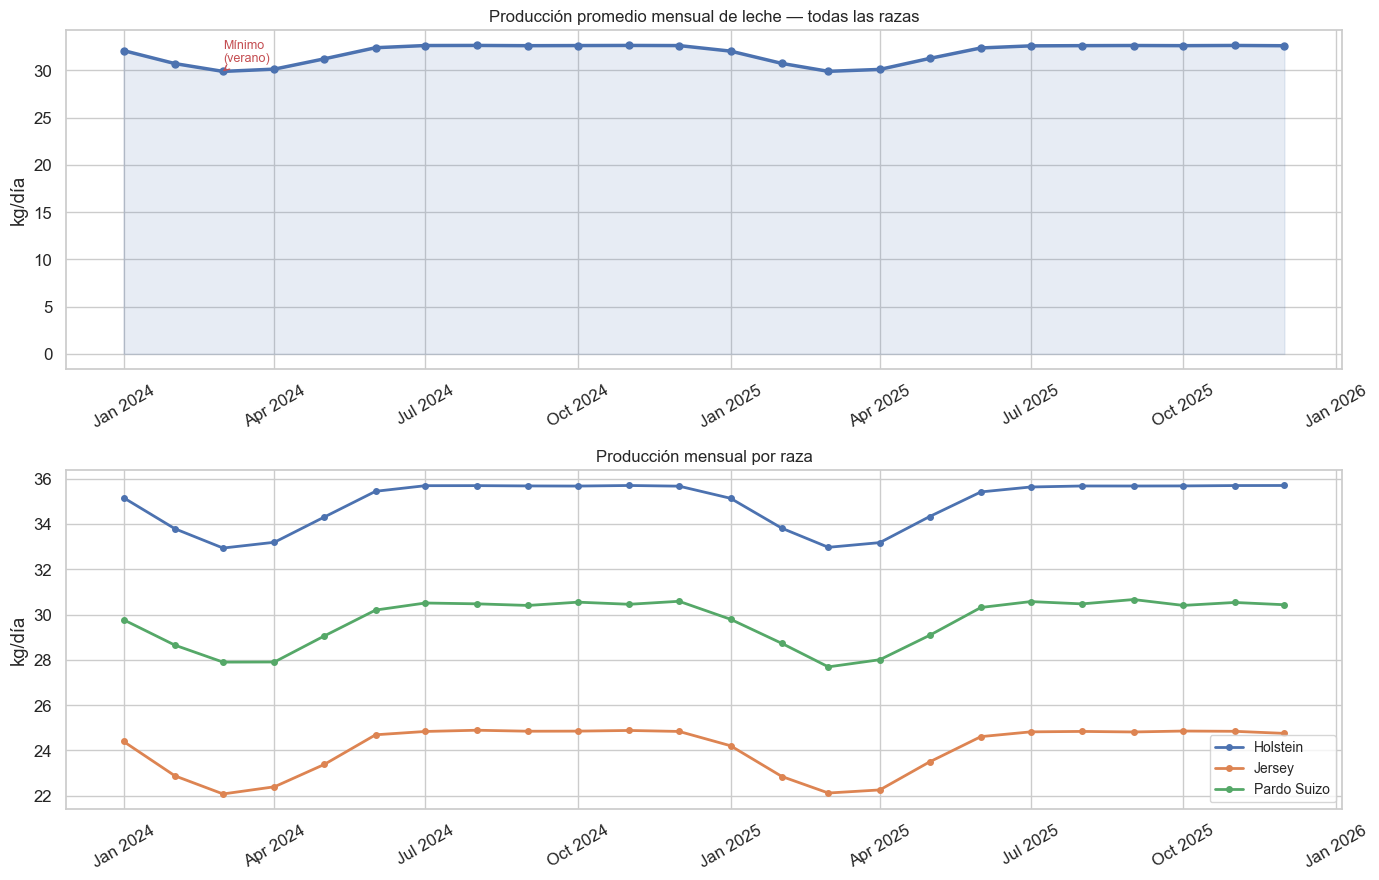

In [16]:
# Leche promedio mensual — total y por raza
ts_total = df.groupby('anio_mes')['leche_kg_dia'].mean().reset_index()
ts_total['dt'] = ts_total['anio_mes'].dt.to_timestamp()

ts_raza = df.groupby(['anio_mes','raza'])['leche_kg_dia'].mean().reset_index()
ts_raza['dt'] = ts_raza['anio_mes'].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Panel 1 — Total
axes[0].plot(ts_total['dt'], ts_total['leche_kg_dia'],
             color='#4C72B0', lw=2.5, marker='o', ms=5)
axes[0].fill_between(ts_total['dt'], ts_total['leche_kg_dia'], alpha=0.13, color='#4C72B0')
axes[0].set_title('Producción promedio mensual de leche — todas las razas', fontsize=12)
axes[0].set_ylabel('kg/día')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].tick_params(axis='x', rotation=30)

# Anotar mínimos de verano
min_idx = ts_total['leche_kg_dia'].idxmin()
axes[0].annotate('Mínimo\n(verano)',
    xy=(ts_total.loc[min_idx,'dt'], ts_total.loc[min_idx,'leche_kg_dia']),
    xytext=(ts_total.loc[min_idx,'dt'], ts_total.loc[min_idx,'leche_kg_dia'] + 1),
    arrowprops=dict(arrowstyle='->', color='#C44E52'),
    fontsize=9, color='#C44E52')

# Panel 2 — Por raza
for raza, grp in ts_raza.groupby('raza'):
    axes[1].plot(grp['dt'], grp['leche_kg_dia'], lw=2, marker='o', ms=4,
                 label=raza, color=PALETTE_RAZA[raza])
axes[1].set_title('Producción mensual por raza', fontsize=12)
axes[1].set_ylabel('kg/día')
axes[1].legend(fontsize=10)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

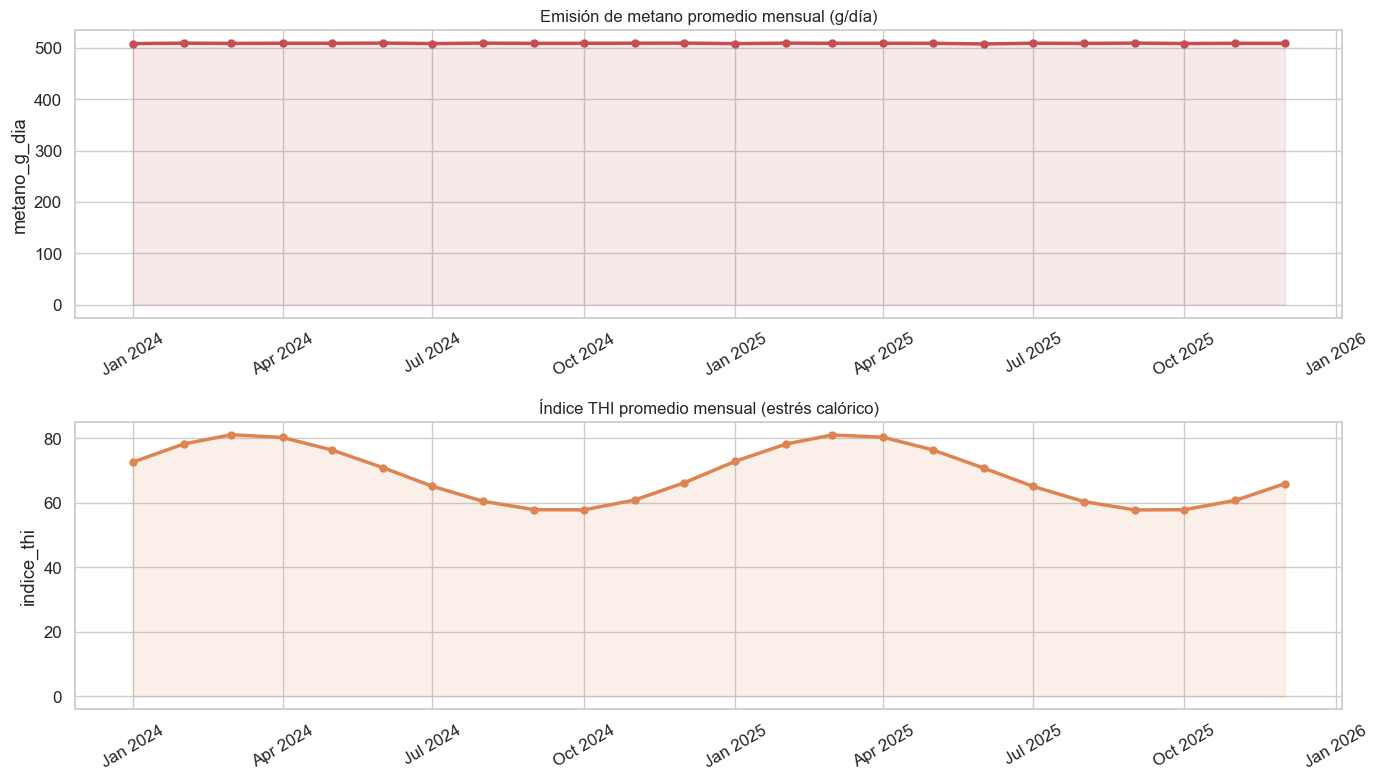


Estacionalidad mensual — leche_kg_dia (promedio por mes del año):
  Ene: █████████████████████ 32.06 kg/día
  Feb: ████████████████████ 30.72 kg/día
  Mar: ███████████████████ 29.89 kg/día
  Abr: ████████████████████ 30.11 kg/día
  May: ████████████████████ 31.23 kg/día
  Jun: █████████████████████ 32.38 kg/día
  Jul: █████████████████████ 32.60 kg/día
  Ago: █████████████████████ 32.62 kg/día
  Sep: █████████████████████ 32.61 kg/día
  Oct: █████████████████████ 32.61 kg/día
  Nov: █████████████████████ 32.63 kg/día
  Dic: █████████████████████ 32.61 kg/día


In [17]:
# Metano y THI temporal
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for col, ax, color, title in zip(
        ['metano_g_dia', 'indice_thi'], axes,
        ['#C44E52', '#DD8452'],
        ['Emisión de metano promedio mensual (g/día)',
         'Índice THI promedio mensual (estrés calórico)']):
    ts2 = df.groupby('anio_mes')[col].mean().reset_index()
    ts2['dt'] = ts2['anio_mes'].dt.to_timestamp()
    ax.plot(ts2['dt'], ts2[col], color=color, lw=2.5, marker='o', ms=5)
    ax.fill_between(ts2['dt'], ts2[col], alpha=0.12, color=color)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(col)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print("\nEstacionalidad mensual — leche_kg_dia (promedio por mes del año):")
monthly_avg = df.groupby('mes')['leche_kg_dia'].mean()
meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
for m, v in zip(meses, monthly_avg):
    bar = '█' * int(v/1.5)
    print(f"  {m}: {bar} {v:.2f} kg/día")

## 8. Análisis de Correlación (Multivariante)

> **Pregunta EDA:** ¿Hay correlación entre variables dependientes e independientes?

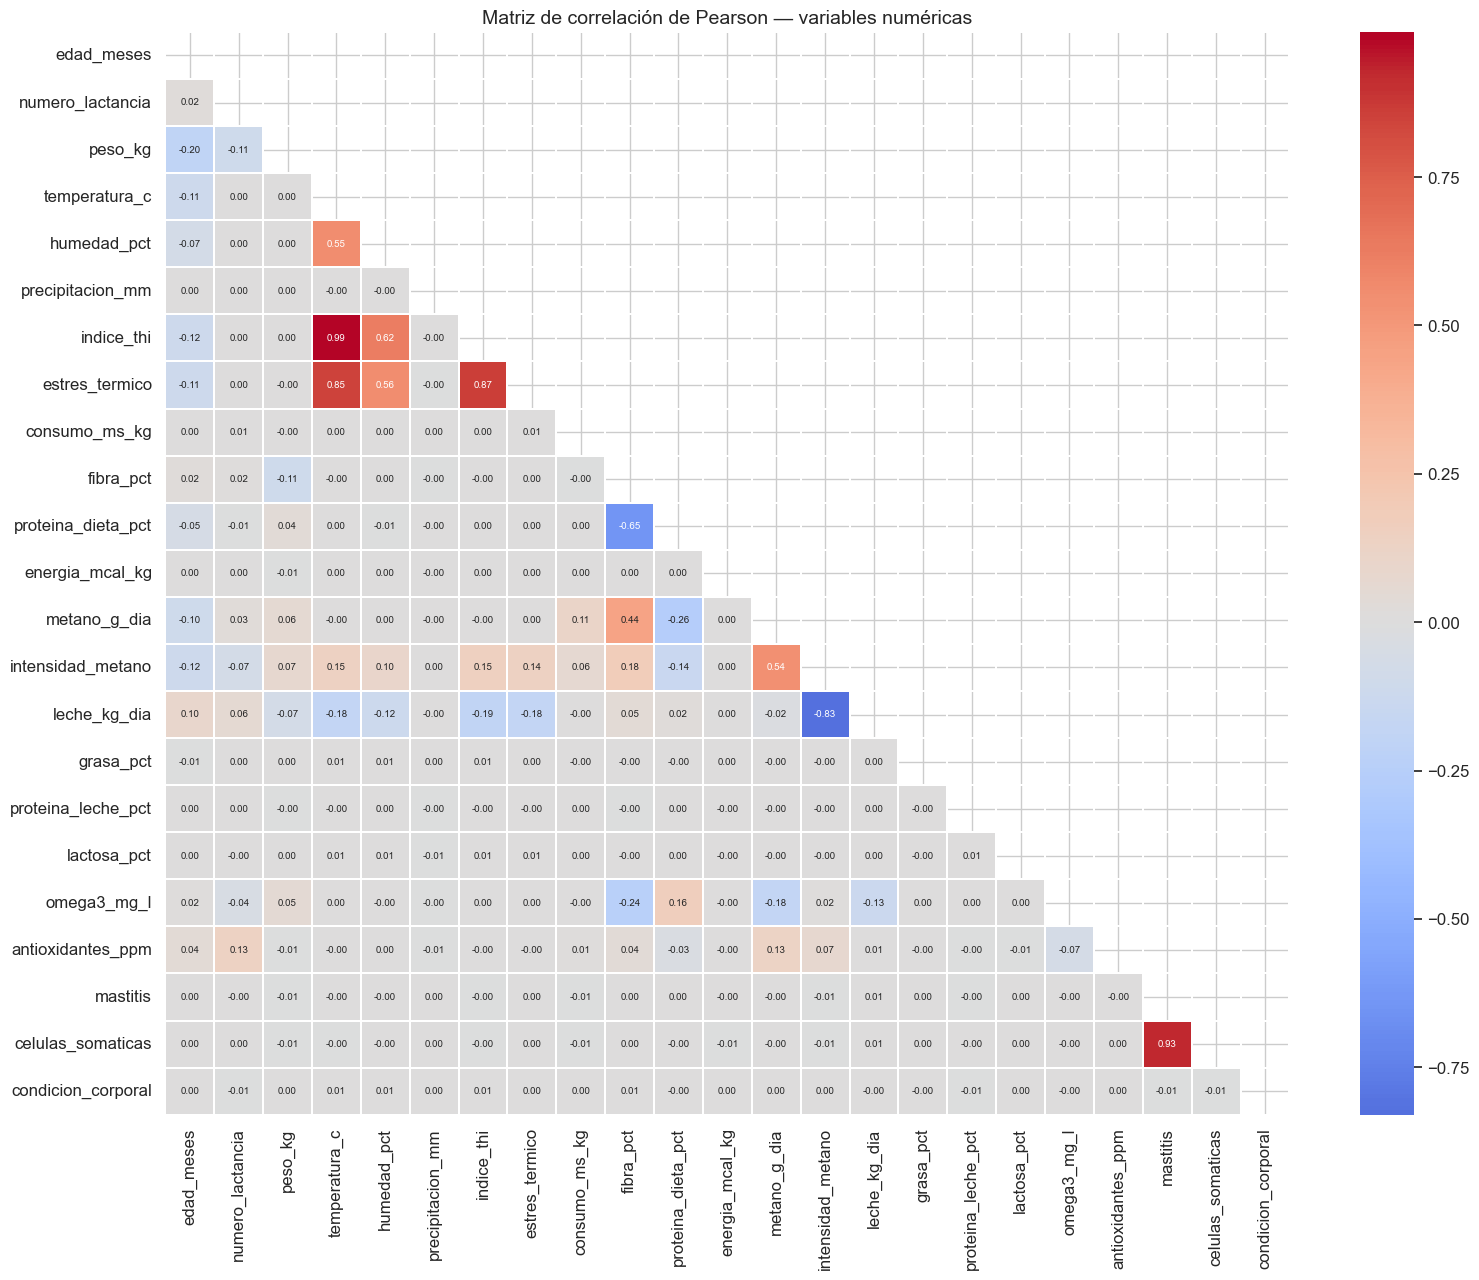

In [18]:
num_df = df.select_dtypes(include='number').drop(columns=['anio','mes'])
corr   = num_df.corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.3, ax=ax, annot_kws={'size': 7})
ax.set_title('Matriz de correlación de Pearson — variables numéricas', fontsize=14)
plt.tight_layout()
plt.show()

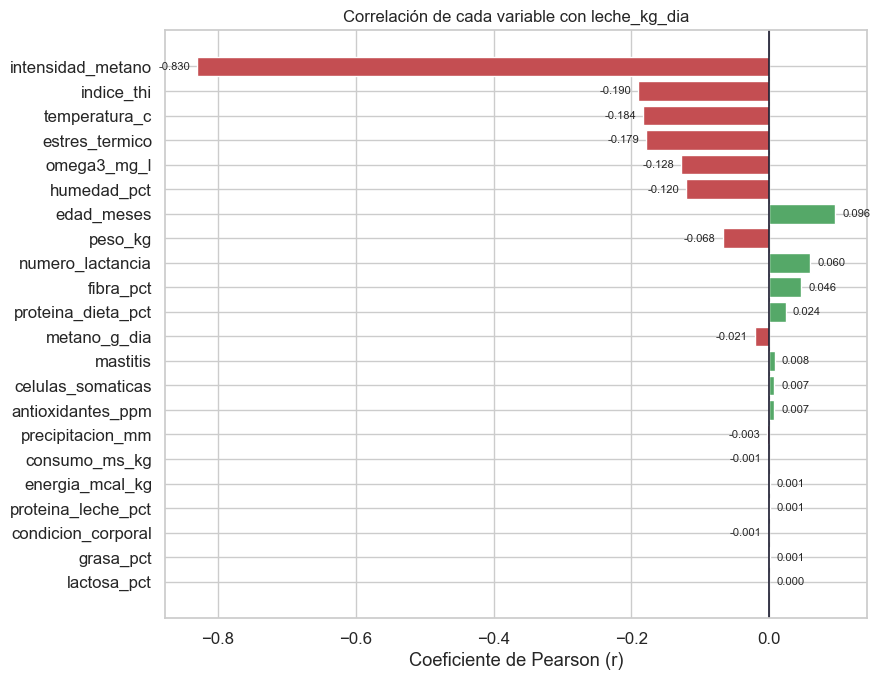


Top 5 correlaciones positivas con leche_kg_dia:
edad_meses            0.095848
numero_lactancia      0.059538
fibra_pct             0.046333
proteina_dieta_pct    0.023877
mastitis              0.007955

Top 5 correlaciones negativas con leche_kg_dia:
intensidad_metano   -0.829980
indice_thi          -0.190002
temperatura_c       -0.183524
estres_termico      -0.178705
omega3_mg_l         -0.127549


In [19]:
# Correlaciones con la variable objetivo leche_kg_dia
corr_leche = (corr['leche_kg_dia']
              .drop('leche_kg_dia')
              .sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(9, 7))
colors_bar = ['#C44E52' if v < 0 else '#55A868' for v in corr_leche.values]
bars = ax.barh(corr_leche.index[::-1], corr_leche.values[::-1], color=colors_bar[::-1])
ax.axvline(0, color='#1a1a2e', lw=1.2)
ax.set_xlabel('Coeficiente de Pearson (r)')
ax.set_title('Correlación de cada variable con leche_kg_dia', fontsize=12)
for bar, v in zip(bars, corr_leche.values[::-1]):
    ax.text(v + (0.01 if v >= 0 else -0.01), bar.get_y()+bar.get_height()/2,
            f'{v:.3f}', va='center', ha='left' if v>=0 else 'right', fontsize=8)
plt.tight_layout()
plt.show()

print("\nTop 5 correlaciones positivas con leche_kg_dia:")
print(corr_leche[corr_leche > 0].head(5).to_string())
print("\nTop 5 correlaciones negativas con leche_kg_dia:")
print(corr_leche[corr_leche < 0].head(5).to_string())

## 9. Análisis Bivariado

> **Pregunta EDA:** ¿Cómo se distribuyen los datos en función de diferentes categorías?

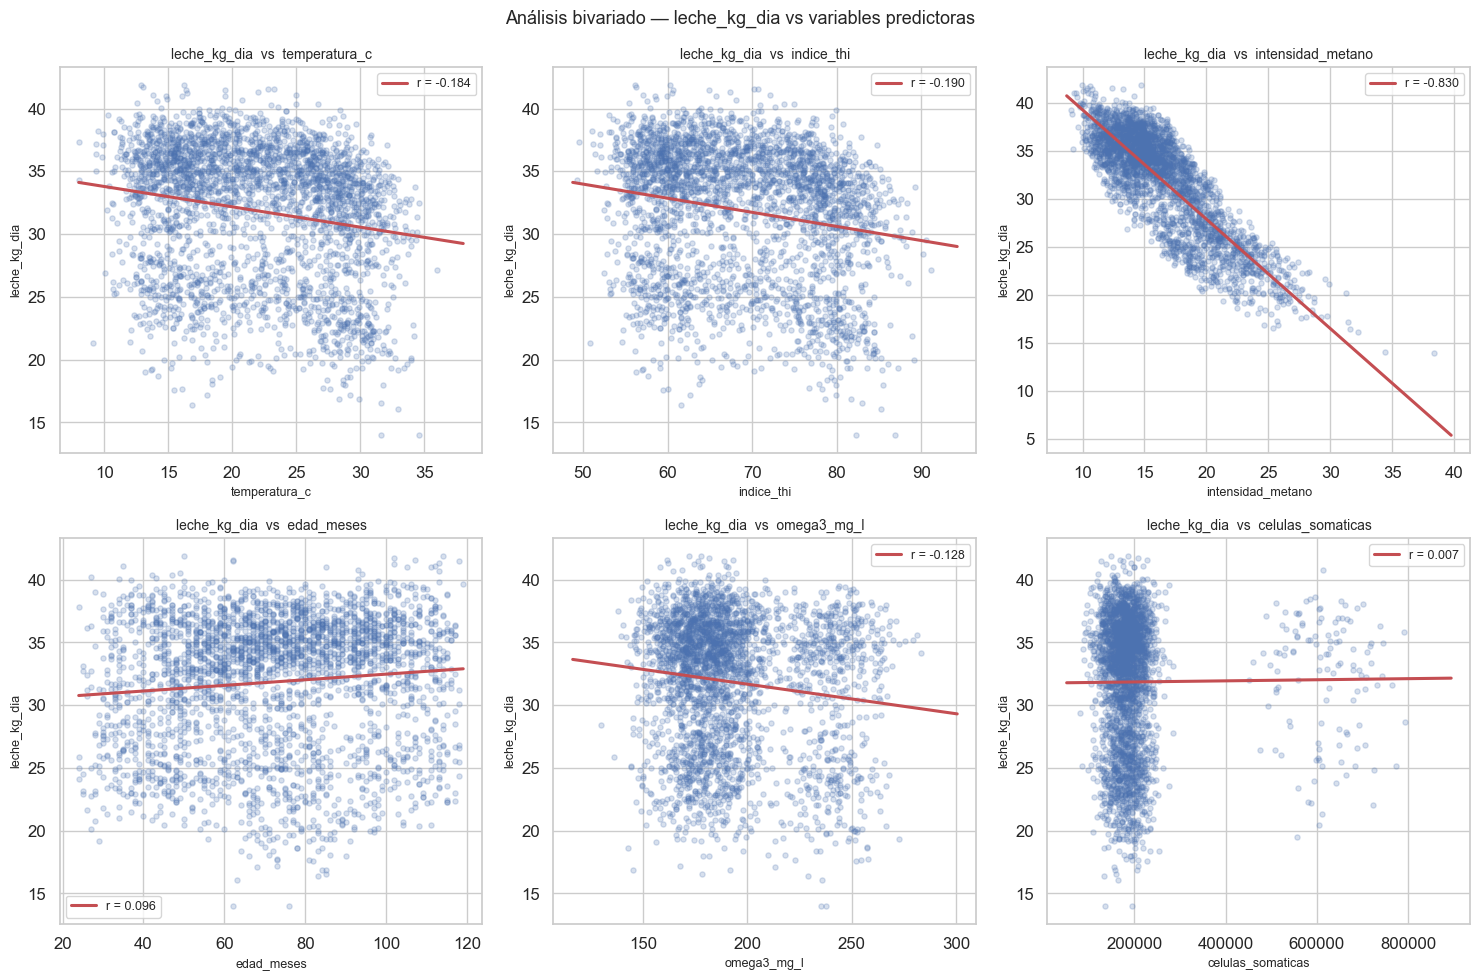

In [20]:
# Scatter plots leche vs variables clave
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
pairs = [('temperatura_c','leche_kg_dia'), ('indice_thi','leche_kg_dia'),
         ('intensidad_metano','leche_kg_dia'), ('edad_meses','leche_kg_dia'),
         ('omega3_mg_l','leche_kg_dia'), ('celulas_somaticas','leche_kg_dia')]

sample = df.sample(3000, random_state=42)

for ax, (x, y) in zip(axes.flat, pairs):
    ax.scatter(sample[x], sample[y], alpha=0.22, s=14, color='#4C72B0')
    m, b, r, p, _ = stats.linregress(df[x], df[y])
    xr = np.linspace(df[x].min(), df[x].max(), 100)
    ax.plot(xr, m*xr+b, color='#C44E52', lw=2.2, label=f'r = {r:.3f}')
    ax.set_xlabel(x, fontsize=9)
    ax.set_ylabel(y, fontsize=9)
    ax.set_title(f'{y}  vs  {x}', fontsize=10)
    ax.legend(fontsize=9)

plt.suptitle('Análisis bivariado — leche_kg_dia vs variables predictoras', fontsize=13)
plt.tight_layout()
plt.show()

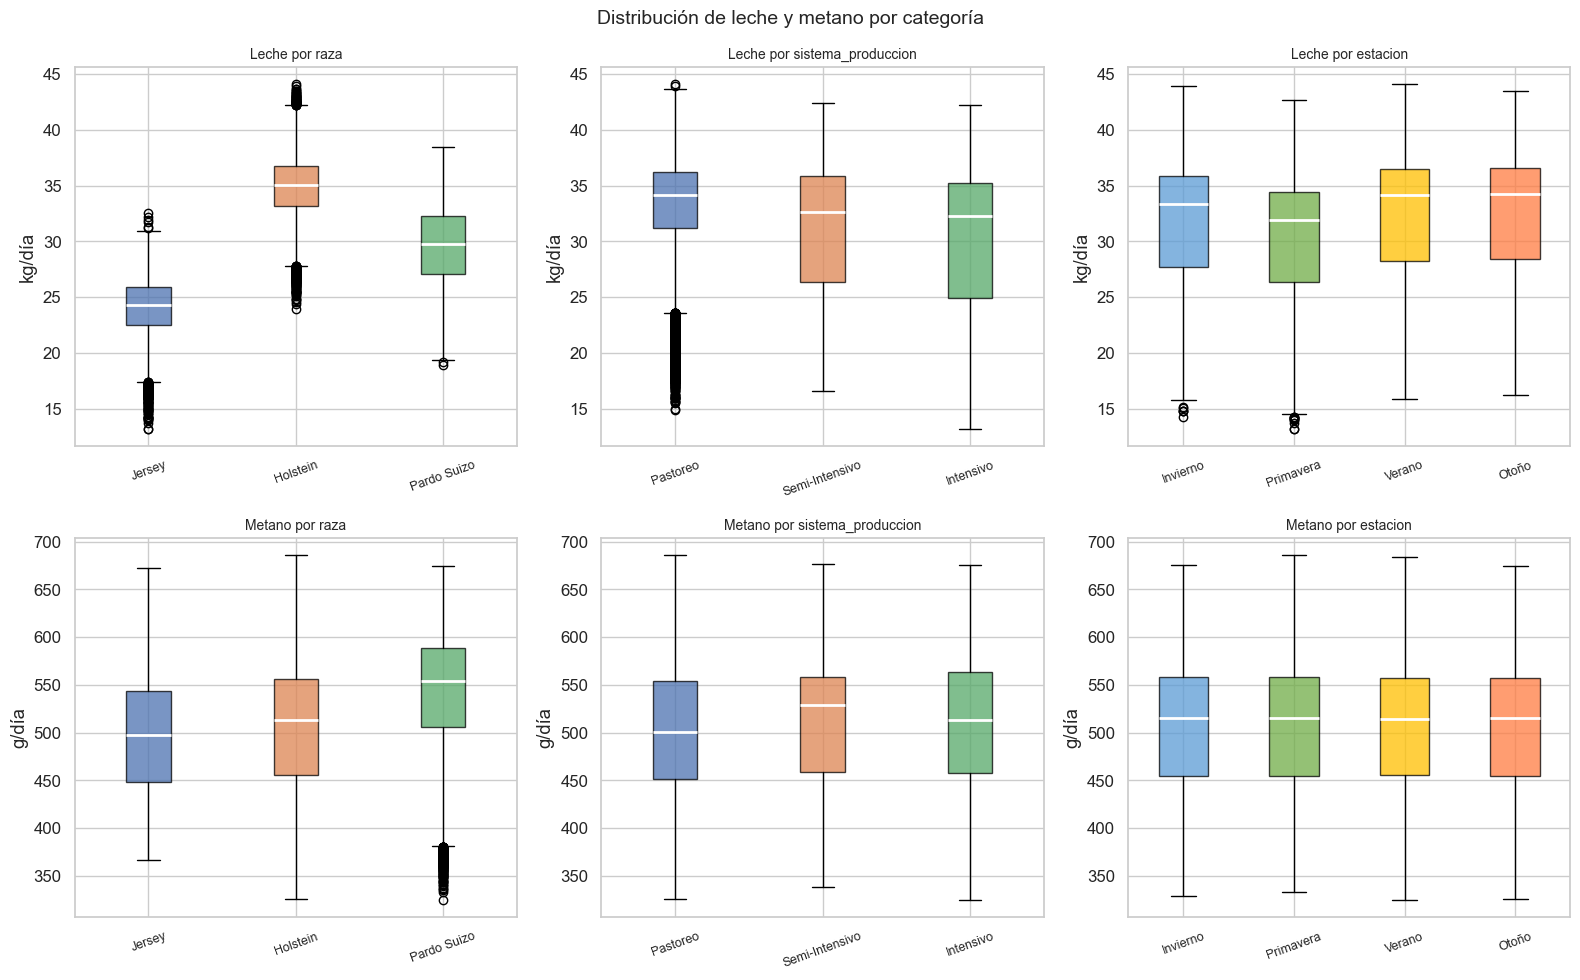

In [21]:
# Boxplots: leche y metano por categorías
groups  = ['raza', 'sistema_produccion', 'estacion']
paletas = [list(PALETTE_RAZA.values()), COLORS[:3], list(PALETTE_STA.values())]
metrics = [('leche_kg_dia','kg/día'), ('metano_g_dia','g/día')]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col_idx, (grp, pal) in enumerate(zip(groups, paletas)):
    cats = df[grp].unique()
    for row_idx, (metric, ylabel) in enumerate(metrics):
        data = [df[df[grp]==cat][metric].values for cat in cats]
        bp = axes[row_idx, col_idx].boxplot(
            data, patch_artist=True, notch=False,
            medianprops=dict(color='white', lw=2))
        for patch, color in zip(bp['boxes'], pal):
            patch.set_facecolor(color)
            patch.set_alpha(0.75)
        axes[row_idx, col_idx].set_xticklabels(cats, rotation=20, fontsize=9)
        axes[row_idx, col_idx].set_title(f'{"Leche" if row_idx==0 else "Metano"} por {grp}', fontsize=10)
        axes[row_idx, col_idx].set_ylabel(ylabel)

plt.suptitle('Distribución de leche y metano por categoría', fontsize=14)
plt.tight_layout()
plt.show()

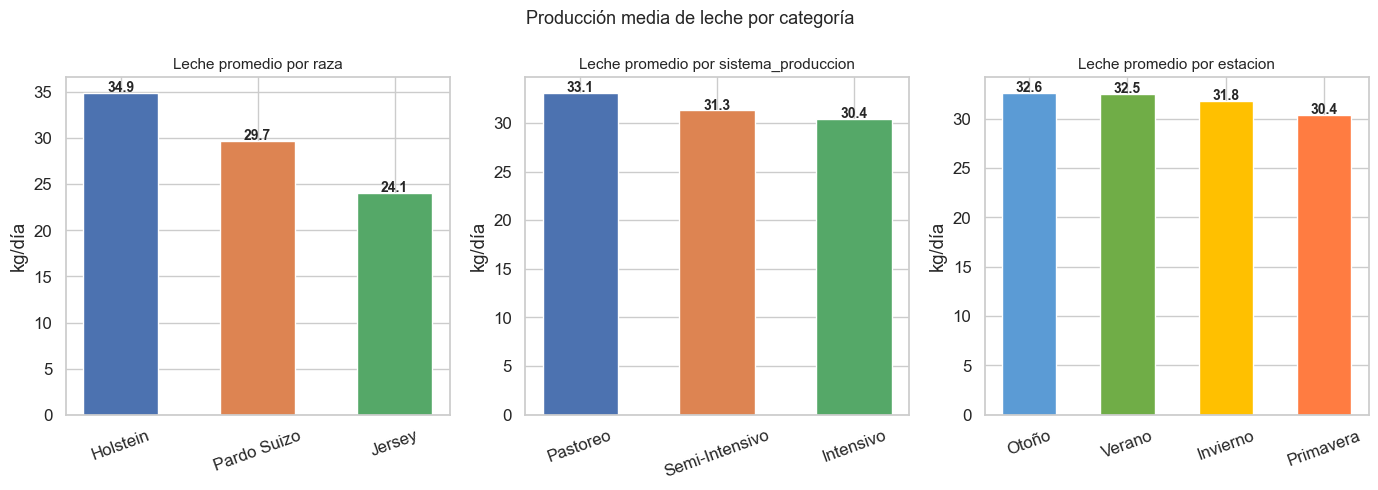

In [22]:
# Leche promedio por raza, sistema, estación (tabla + barras)
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col, pal in zip(axes, groups, paletas):
    means = df.groupby(col)['leche_kg_dia'].mean().sort_values(ascending=False)
    bars  = ax.bar(means.index, means.values, color=pal[:len(means)], edgecolor='white', width=0.55)
    ax.set_title(f'Leche promedio por {col}', fontsize=11)
    ax.set_ylabel('kg/día')
    ax.tick_params(axis='x', rotation=20)
    for bar, v in zip(bars, means.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Producción media de leche por categoría', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Estrés Térmico y Mastitis por Estación

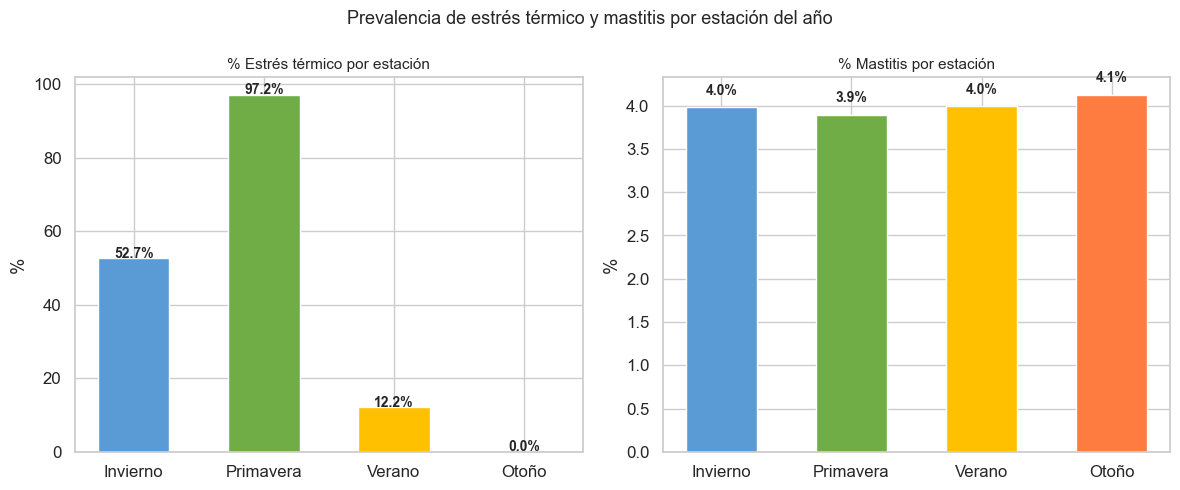

In [23]:
order = ['Invierno','Primavera','Verano','Otoño']
cols4 = [PALETTE_STA[s] for s in order]

et_vals  = [df[df['estacion']==s]['estres_termico'].mean()*100 for s in order]
mas_vals = [df[df['estacion']==s]['mastitis'].mean()*100 for s in order]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, vals, title in zip(axes, [et_vals, mas_vals],
        ['% Estrés térmico por estación', '% Mastitis por estación']):
    bars = ax.bar(order, vals, color=cols4, edgecolor='white', width=0.55)
    ax.set_ylabel('%')
    ax.set_title(title, fontsize=11)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.15,
                f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Prevalencia de estrés térmico y mastitis por estación del año', fontsize=13)
plt.tight_layout()
plt.show()

## 11. Preprocesamiento Justificado

### 11.1 Transformaciones aplicadas

In [24]:
df_proc = df.copy()

# 1. Transformación logarítmica — celulas_somaticas
df_proc['log_celulas_somaticas'] = np.log1p(df_proc['celulas_somaticas'])

# 2. Eliminar variable redundante
df_proc = df_proc.drop(columns=['nombre_vaca'])

# 3. Eliminar temperatura_c (multicolineal con indice_thi)
df_proc = df_proc.drop(columns=['temperatura_c'])

# 4. Encoding cíclico — mes y dia_semana
df_proc['mes_sin'] = np.sin(2 * np.pi * df_proc['mes'] / 12)
df_proc['mes_cos'] = np.cos(2 * np.pi * df_proc['mes'] / 12)

# 5. Ordinal encoding — sistema_produccion
sistema_map = {'Pastoreo': 0, 'Semi-Intensivo': 1, 'Intensivo': 2}
df_proc['sistema_produccion_ord'] = df_proc['sistema_produccion'].map(sistema_map)

# 6. One-hot encoding — raza, tipo_alimento, aditivo_1, aditivo_2, estacion
df_proc = pd.get_dummies(df_proc, columns=['raza','tipo_alimento','aditivo_1','aditivo_2','estacion'],
                          drop_first=False, dtype=int)

print(f"Dataset original: {df.shape}")
print(f"Dataset procesado: {df_proc.shape}")
print("\nNuevas columnas agregadas:")
new_cols = [c for c in df_proc.columns if c not in df.columns]
print(new_cols)

Dataset original: (73000, 36)
Dataset procesado: (73000, 52)

Nuevas columnas agregadas:
['log_celulas_somaticas', 'mes_sin', 'mes_cos', 'sistema_produccion_ord', 'raza_Holstein', 'raza_Jersey', 'raza_Pardo Suizo', 'tipo_alimento_Alta Energia', 'tipo_alimento_Alta Fibra', 'tipo_alimento_Base', 'tipo_alimento_Omega Plus', 'aditivo_1_Algas', 'aditivo_1_Ninguno', 'aditivo_1_Probióticos', 'aditivo_1_Taninos', 'aditivo_2_Aceites', 'aditivo_2_Levadura', 'aditivo_2_Minerales', 'aditivo_2_Ninguno', 'estacion_Invierno', 'estacion_Otoño', 'estacion_Primavera', 'estacion_Verano']


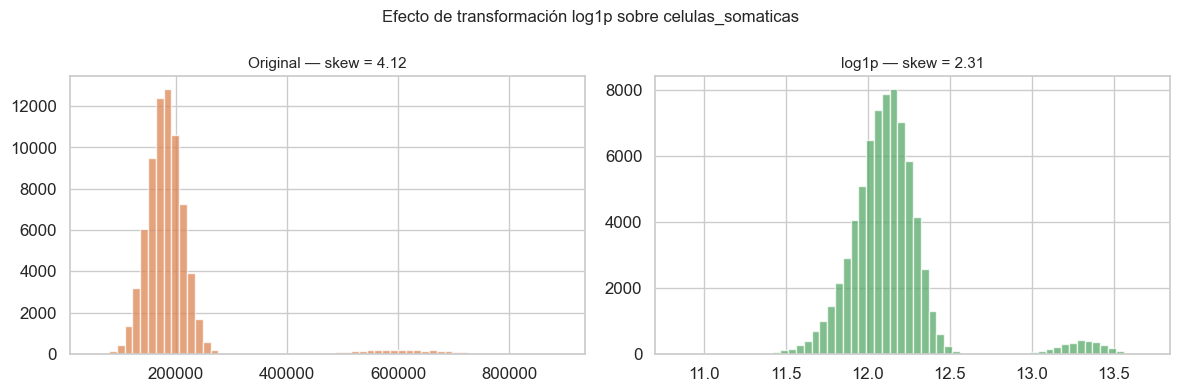

In [25]:
# Verificar mejora en skewness post-transformación
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['celulas_somaticas'], bins=60, color='#DD8452', alpha=0.75, edgecolor='white')
axes[0].set_title(f'Original — skew = {df["celulas_somaticas"].skew():.2f}', fontsize=11)

axes[1].hist(df_proc['log_celulas_somaticas'], bins=60, color='#55A868', alpha=0.75, edgecolor='white')
axes[1].set_title(f'log1p — skew = {df_proc["log_celulas_somaticas"].skew():.2f}', fontsize=11)

plt.suptitle('Efecto de transformación log1p sobre celulas_somaticas', fontsize=12)
plt.tight_layout()
plt.show()

## 12. Conclusiones del EDA

### 📌 Resumen de hallazgos

| # | Hallazgo | Detalle |
|---|----------|---------|
| 1 | **Sin valores faltantes** | 100% completitud en las 35 columnas (73,000 registros) |
| 2 | **Outlier crítico** | `celulas_somaticas` tiene 4.43% de outliers y skew = 4.12 → transformación log1p obligatoria |
| 3 | **Multicolinealidad** | `temperatura_c` e `indice_thi` tienen r ≈ 0.97 → eliminar una de las dos |
| 4 | **Alta cardinalidad** | `id_vaca`/`nombre_vaca` (100 valores únicos) → target encoding o efectos aleatorios |
| 5 | **Estacionalidad clara** | Producción cae en verano (~-15%) por estrés calórico (THI > 72) |
| 6 | **Correlación dominante** | `intensidad_metano` ↔ `leche_kg_dia` (r = **-0.83**) — relación de eficiencia |
| 7 | **Efecto raza** | Holstein ≈ 35 kg/día vs Jersey ≈ 24 kg/día (+45% diferencia) |
| 8 | **Desbalance severo** | `mastitis` al 4% → usar SMOTE o `class_weight='balanced'` |
| 9 | **Sin tendencia secular** | La producción media es estable en los 24 meses (sin drift) |
| 10 | **Clima como predictor** | THI y temperatura son los factores ambientales más influyentes |

---

### 🔧 Operaciones de preprocesamiento aplicadas

| Operación | Variable(s) | Justificación |
|-----------|------------|---------------|
| `log1p` | `celulas_somaticas` | Skew = 4.12 → normalizar distribución |
| Eliminar | `nombre_vaca` | Duplica información de `id_vaca` |
| Eliminar | `temperatura_c` | Multicolineal con `indice_thi` (r = 0.97) |
| Encoding cíclico | `mes`, `dia_semana` | Variables cíclicas — preservar distancia |
| Ordinal encoding | `sistema_produccion` | Orden lógico: Pastoreo → Semi → Intensivo |
| One-hot encoding | `raza`, `tipo_alimento`, `aditivo_1`, `aditivo_2`, `estacion` | Cardinalidad baja, sin orden |
| Target encoding | `id_vaca` | Alta cardinalidad (100 valores) |
| Balanceo SMOTE | `mastitis` | Desbalance 24:1 → modelos sesgados sin corrección |

---

### 🔍 Relaciones más importantes para modelado

1. **`intensidad_metano` → `leche_kg_dia`** (r = -0.83): El predictor más fuerte. Vacas más productivas son más eficientes en la conversión energética.
2. **`indice_thi` → `leche_kg_dia`** (r = -0.19): El calor reduce significativamente la producción.
3. **`raza` → `leche_kg_dia`**: La raza es uno de los factores categóricos más diferenciadores.
4. **`estacion` + `mes` → patrón estacional**: Incorporar como features temporales es esencial.
5. **`celulas_somaticas` → `mastitis`**: Variable potencialmente predictora de salud (con transformación log).
